# AeroNet Lite – Module 5B: Anomaly Detection
**BS Data Science – AI Semester Project SP2026**

This notebook trains classification models on **synthetic drone telemetry** to detect flight anomalies.

Four anomaly classes are defined using clearly explained synthetic rules:
| Class | Synthetic Rule |
|---|---|
| Normal | Battery decreases gradually, route deviation low |
| Battery Anomaly | Battery drops much faster than expected |
| Route Anomaly | Drone deviates significantly from planned path |
| Sensor Spike | Altitude or speed suddenly jumps |

**Models used:** Decision Tree, Random Forest  
**Metrics:** Accuracy, Confusion Matrix, Classification Report

In [14]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

print('All imports successful.')

All imports successful.


In [15]:
# ── Cell 2: Generate Synthetic Telemetry Dataset ─────────────────────────────
np.random.seed(42)

def generate_telemetry(n_normal=600, n_anomaly_each=200):
    records = []

    # Normal
    for _ in range(n_normal):
        records.append({
            'battery_drop':    np.random.uniform(1.0, 4.0),
            'speed':           np.random.uniform(5.0, 15.0),
            'route_deviation': np.random.uniform(0.0, 0.5),
            'altitude_change': np.random.uniform(-1.0, 1.0),
            'speed_change':    np.random.uniform(-2.0, 2.0),
            'label': 'Normal'
        })

    # Battery Anomaly
    for _ in range(n_anomaly_each):
        records.append({
            'battery_drop':    np.random.uniform(15.0, 40.0),
            'speed':           np.random.uniform(4.0, 14.0),
            'route_deviation': np.random.uniform(0.0, 0.4),
            'altitude_change': np.random.uniform(-1.0, 1.0),
            'speed_change':    np.random.uniform(-2.0, 2.0),
            'label': 'Battery Anomaly'
        })

    # Route Anomaly
    for _ in range(n_anomaly_each):
        records.append({
            'battery_drop':    np.random.uniform(1.0, 5.0),
            'speed':           np.random.uniform(5.0, 15.0),
            'route_deviation': np.random.uniform(3.0, 8.0),
            'altitude_change': np.random.uniform(-1.0, 1.0),
            'speed_change':    np.random.uniform(-2.0, 2.0),
            'label': 'Route Anomaly'
        })

    # Sensor Spike
    for _ in range(n_anomaly_each):
        records.append({
            'battery_drop':    np.random.uniform(1.0, 5.0),
            'speed':           np.random.uniform(5.0, 15.0),
            'route_deviation': np.random.uniform(0.0, 0.5),
            'altitude_change': np.random.uniform(10.0, 30.0),
            'speed_change':    np.random.uniform(20.0, 50.0),
            'label': 'Sensor Spike'
        })

    return pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)

df = generate_telemetry()
print(f'Dataset shape: {df.shape}')
print(df['label'].value_counts())
df.head()

Dataset shape: (1200, 6)
label
Normal             600
Sensor Spike       200
Route Anomaly      200
Battery Anomaly    200
Name: count, dtype: int64


,battery_drop,speed,route_deviation,altitude_change,speed_change,label
0,3.874797,10.862355,0.246184,13.846315,33.918088,Sensor Spike
1,4.802131,5.220661,7.912606,-0.827736,1.257547,Route Anomaly
2,1.487851,14.109272,0.411269,0.899600,0.902878,Normal
3,2.341167,9.603583,0.432282,0.093296,-0.478398,Normal
4,1.091501,5.373482,0.411300,-0.279619,-1.491758,Normal


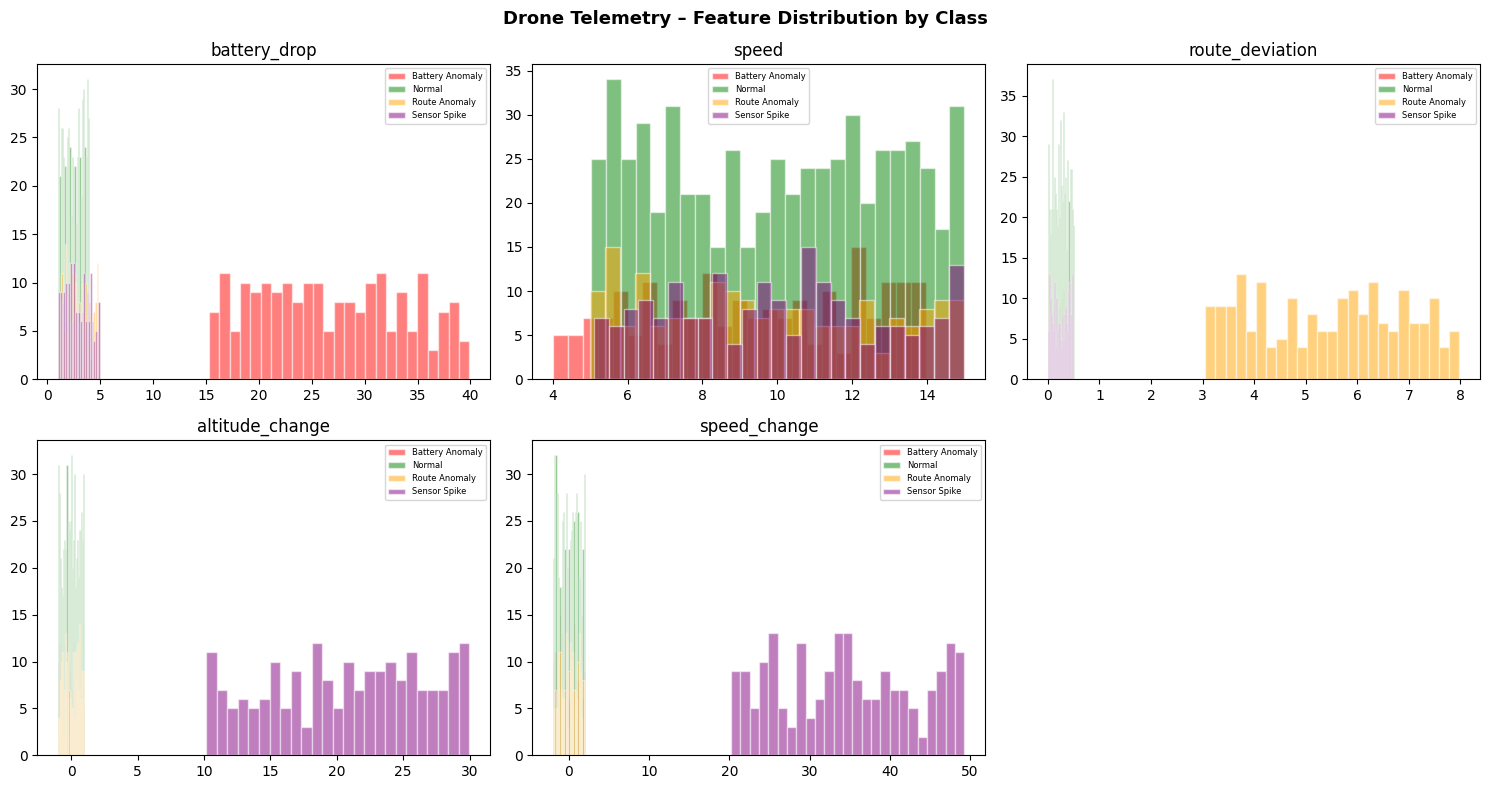

In [16]:
# ── Cell 3: Exploratory Data Analysis ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['battery_drop', 'speed', 'route_deviation', 'altitude_change', 'speed_change']
colors   = {'Normal': 'green', 'Battery Anomaly': 'red',
            'Route Anomaly': 'orange', 'Sensor Spike': 'purple'}

for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    for label, grp in df.groupby('label'):
        ax.hist(grp[feat], bins=25, alpha=0.5, label=label,
                color=colors[label], edgecolor='white')
    ax.set_title(feat)
    ax.legend(fontsize=6)

axes[1][2].axis('off')
plt.suptitle('Drone Telemetry – Feature Distribution by Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../report/figures', exist_ok=True)
plt.savefig('../report/figures/anomaly_eda.png', dpi=150, bbox_inches='tight')
plt.show()

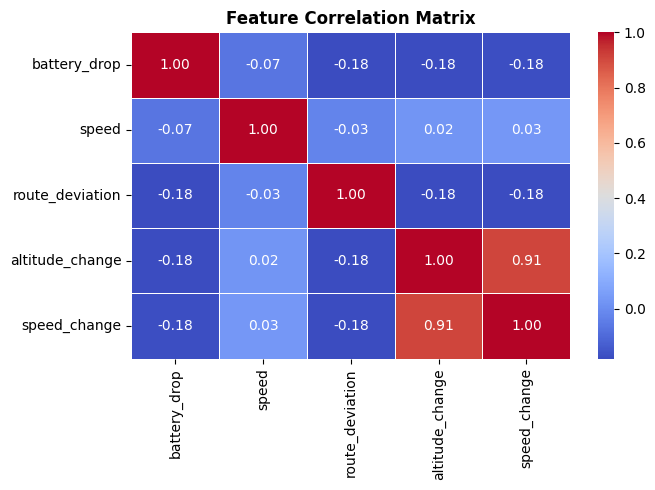

In [17]:
# ── Cell 4: Feature Correlation Heatmap ──────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/figures/anomaly_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Cell 5: Prepare Features and Labels ──────────────────────────────────────
X = df[features]
le = LabelEncoder()
y = le.fit_transform(df['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Classes: {list(le.classes_)}')
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Classes: ['Battery Anomaly', 'Normal', 'Route Anomaly', 'Sensor Spike']
Train: 960 | Test: 240


In [19]:
# ── Cell 6: Decision Tree Classifier ─────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {acc_dt:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Decision Tree Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

Battery Anomaly       1.00      1.00      1.00        40
         Normal       1.00      1.00      1.00       120
  Route Anomaly       1.00      1.00      1.00        40
   Sensor Spike       1.00      1.00      1.00        40

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



In [20]:
# ── Cell 7: Random Forest Classifier ─────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {acc_rf:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

Battery Anomaly       1.00      1.00      1.00        40
         Normal       1.00      1.00      1.00       120
  Route Anomaly       1.00      1.00      1.00        40
   Sensor Spike       1.00      1.00      1.00        40

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



In [21]:
# ── Cell 8: KNN Classifier (Comparison) ──────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

print(f'KNN Accuracy         : {acc_knn:.4f}')
print(f'Naive Bayes Accuracy : {acc_nb:.4f}')

KNN Accuracy         : 1.0000
Naive Bayes Accuracy : 1.0000


        Model  Accuracy
Decision Tree       1.0
Random Forest       1.0
          KNN       1.0
  Naive Bayes       1.0


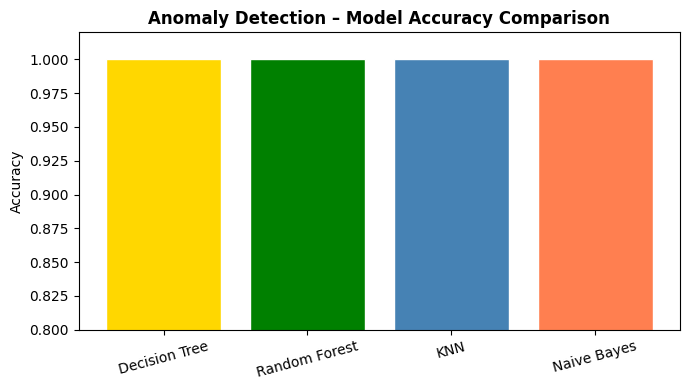

In [22]:
# ── Cell 9: Model Comparison Summary ─────────────────────────────────────────
summary = pd.DataFrame({
    'Model':    ['Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes'],
    'Accuracy': [round(acc_dt, 4), round(acc_rf, 4),
                 round(acc_knn, 4), round(acc_nb, 4)]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.bar(summary['Model'], summary['Accuracy'],
        color=['gold', 'green', 'steelblue', 'coral'], edgecolor='white')
plt.ylim(0.8, 1.02)
plt.title('Anomaly Detection – Model Accuracy Comparison',
          fontsize=12, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../report/figures/anomaly_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

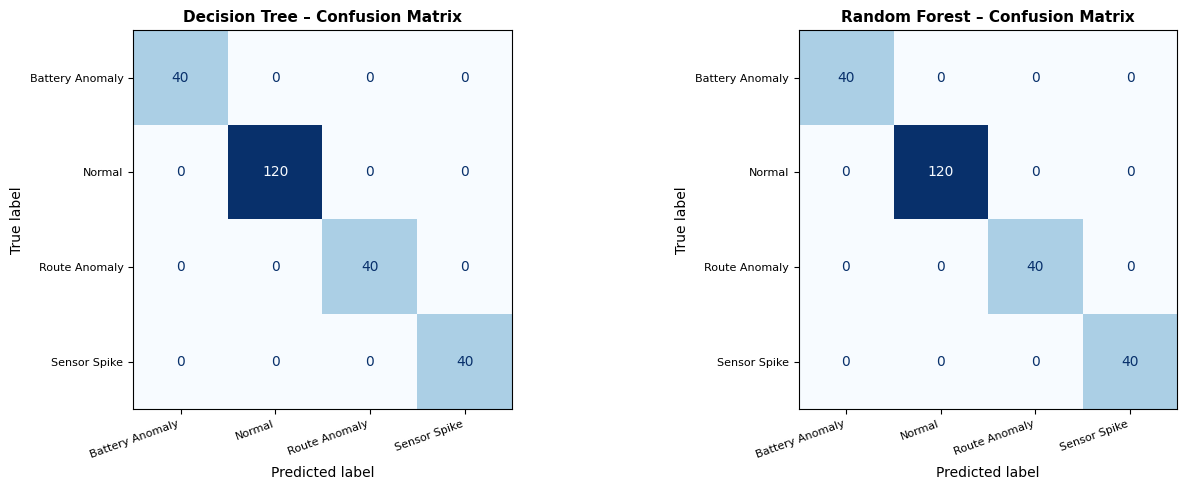

In [23]:
# ── Cell 10: Confusion Matrices (Decision Tree + Random Forest) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(axes,
    [y_pred_dt, y_pred_rf],
    ['Decision Tree', 'Random Forest']):

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} – Confusion Matrix', fontsize=11, fontweight='bold')
    ax.set_xticklabels(le.classes_, rotation=20, ha='right', fontsize=8)
    ax.set_yticklabels(le.classes_, fontsize=8)

plt.tight_layout()
plt.savefig('../report/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

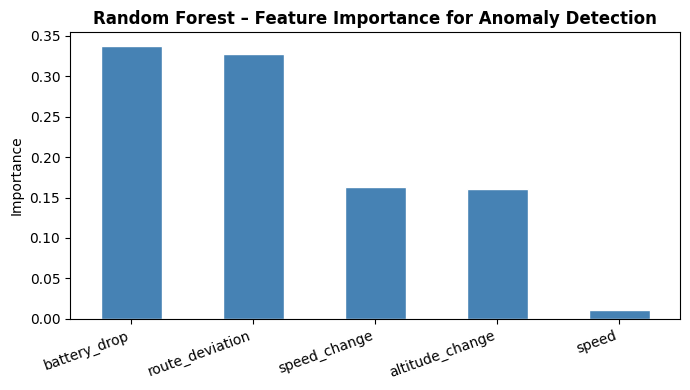

battery_drop       0.337418
route_deviation    0.328067
speed_change       0.163092
altitude_change    0.160590
speed              0.010833
dtype: float64


In [24]:
# ── Cell 11: Feature Importance (Random Forest) ───────────────────────────────
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Random Forest – Feature Importance for Anomaly Detection',
          fontsize=12, fontweight='bold')
plt.ylabel('Importance')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../report/figures/anomaly_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(importances)

In [25]:
# ── Cell 12: Real-Time Prediction Example ────────────────────────────────────
# Simulate a new drone telemetry reading and predict its class
new_telemetry = pd.DataFrame([{
    'battery_drop':    25.0,    # high -> likely Battery Anomaly
    'speed':           10.0,
    'route_deviation': 0.3,
    'altitude_change': 0.5,
    'speed_change':    1.0
}])

pred_encoded = rf.predict(new_telemetry)[0]
pred_class   = le.inverse_transform([pred_encoded])[0]
proba        = rf.predict_proba(new_telemetry)[0]

print(f'Predicted Anomaly Class: {pred_class}')
print('Class Probabilities:')
for cls, prob in zip(le.classes_, proba):
    print(f'  {cls:20s}: {prob:.4f}')

Predicted Anomaly Class: Battery Anomaly
Class Probabilities:
  Battery Anomaly     : 1.0000
  Normal              : 0.0000
  Route Anomaly       : 0.0000
  Sensor Spike        : 0.0000


In [26]:
# ── Cell 13: Save Telemetry Dataset ──────────────────────────────────────────
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/drone_telemetry.csv', index=False)
print('Saved: data/processed/drone_telemetry.csv')

print('\n=== Anomaly Detection Complete ===')
print(f'Best Model : Random Forest')
print(f'Accuracy   : {acc_rf:.4f}')
print(f'Classes    : {list(le.classes_)}')

Saved: data/processed/drone_telemetry.csv

=== Anomaly Detection Complete ===
Best Model : Random Forest
Accuracy   : 1.0000
Classes    : ['Battery Anomaly', 'Normal', 'Route Anomaly', 'Sensor Spike']
